In [33]:
import pandas as pd    #importing libraries
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt



# Introduction

This project analyzes clinical and demographic data to predict stroke risk using interpretable machine learning. Because stroke cases are rare, the analysis focuses on imbalance-aware evaluation, threshold optimization, and explainable feature contributions.



# Objective:

- Predict stroke risk using clinical and demographic features

- Dataset contains imbalanced outcome (stroke is rare)

- Focus on interpretable healthcare risk modeling

- Evaluate model beyond accuracy using imbalance-aware metrics

# Modeling Challenges

- Stroke is a rare outcome, creating severe class imbalance that can bias models toward majority predictions.

- Some clinical variables naturally contain extreme but medically valid values (e.g., glucose), requiring careful handling rather than removal.

- Misclassification costs are asymmetric — missing a true stroke case is more critical than raising a false alarm.

- Model evaluation must therefore balance detection sensitivity and prediction reliability rather than relying on accuracy alone.

In [34]:
df=pd.read_csv("/kaggle/input/datasets/fedesoriano/stroke-prediction-dataset/healthcare-dataset-stroke-data.csv")
df.head()  #Loading the data set and initial checking

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1


In [35]:
df.head().T  # TRANSFORMING the row header names for clarity

,0,1,2,3,4
id,9046,51676,31112,60182,1665
gender,Male,Female,Male,Female,Female
age,67.0,61.0,80.0,49.0,79.0
hypertension,0,0,0,0,1
heart_disease,1,0,1,0,0
ever_married,Yes,Yes,Yes,Yes,Yes
work_type,Private,Self-employed,Private,Private,Self-employed
Residence_type,Urban,Rural,Rural,Urban,Rural
avg_glucose_level,228.69,202.21,105.92,171.23,174.12
bmi,36.6,NaN,32.5,34.4,24.0


In [36]:
df.info()  # Information about data types and consistency check. Also helps in identifying null values

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5110 entries, 0 to 5109
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 5110 non-null   int64  
 1   gender             5110 non-null   object 
 2   age                5110 non-null   float64
 3   hypertension       5110 non-null   int64  
 4   heart_disease      5110 non-null   int64  
 5   ever_married       5110 non-null   object 
 6   work_type          5110 non-null   object 
 7   Residence_type     5110 non-null   object 
 8   avg_glucose_level  5110 non-null   float64
 9   bmi                4909 non-null   float64
 10  smoking_status     5110 non-null   object 
 11  stroke             5110 non-null   int64  
dtypes: float64(3), int64(4), object(5)
memory usage: 479.2+ KB


In [37]:
df.shape    # Number of rows and columns

(5110, 12)

In [38]:
df.describe()    # Understanding the dataset further by identifying count,mean/ average, minimum, maximum etc
                 # Central Tendency(mean) as well as dispersion(std)check

,id,age,hypertension,heart_disease,avg_glucose_level,bmi,stroke
count,5110.000000,5110.000000,5110.000000,5110.000000,5110.000000,4909.000000,5110.000000
mean,36517.829354,43.226614,0.097456,0.054012,106.147677,28.893237,0.048728
std,21161.721625,22.612647,0.296607,0.226063,45.283560,7.854067,0.215320
min,67.000000,0.080000,0.000000,0.000000,55.120000,10.300000,0.000000
25%,17741.250000,25.000000,0.000000,0.000000,77.245000,23.500000,0.000000
50%,36932.000000,45.000000,0.000000,0.000000,91.885000,28.100000,0.000000
75%,54682.000000,61.000000,0.000000,0.000000,114.090000,33.100000,0.000000
max,72940.000000,82.000000,1.000000,1.000000,271.740000,97.600000,1.000000


In [39]:
df['stroke'].value_counts()

stroke
0    4861
1     249
Name: count, dtype: int64

Text(0.5, 1.0, 'Stroke distribution')

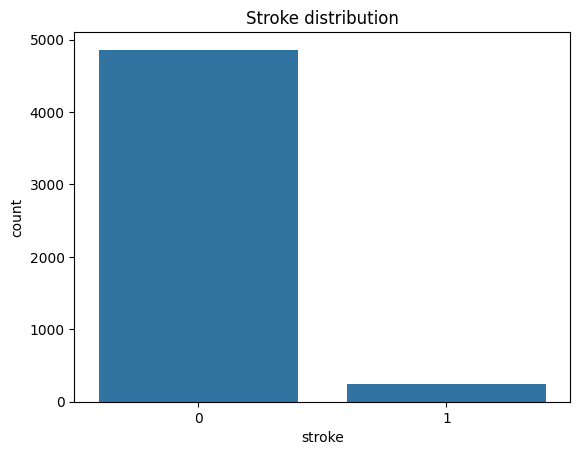

In [40]:
sns.countplot(x='stroke', data=df)
plt.title("Stroke distribution")


# data cleaning :

#1 null values
#2 duplicate values
#3 outlier analysis

In [41]:
df.isnull().sum()      # check null values and sum them

id                     0
gender                 0
age                    0
hypertension           0
heart_disease          0
ever_married           0
work_type              0
Residence_type         0
avg_glucose_level      0
bmi                  201
smoking_status         0
stroke                 0
dtype: int64

In [42]:
df.duplicated().sum()

np.int64(0)

In [43]:
col= list(df.columns)
col

['id',
 'gender',
 'age',
 'hypertension',
 'heart_disease',
 'ever_married',
 'work_type',
 'Residence_type',
 'avg_glucose_level',
 'bmi',
 'smoking_status',
 'stroke']

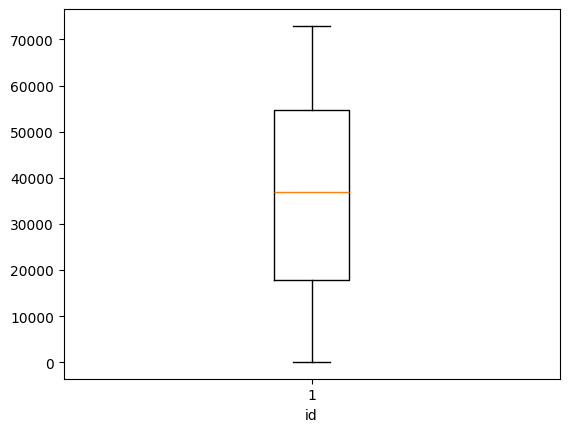

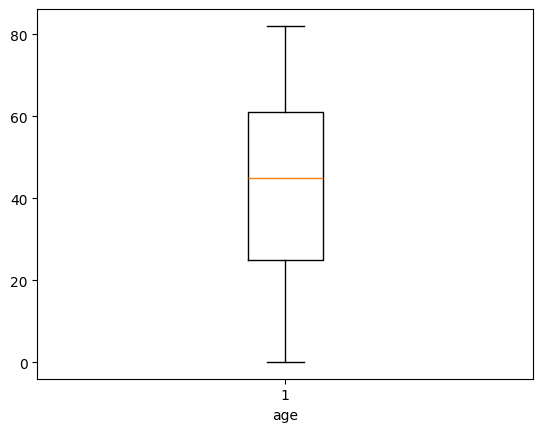

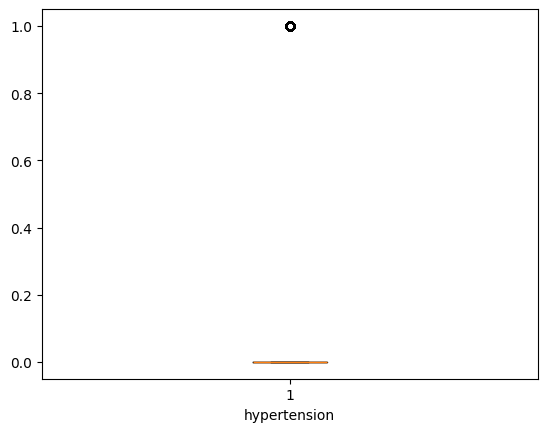

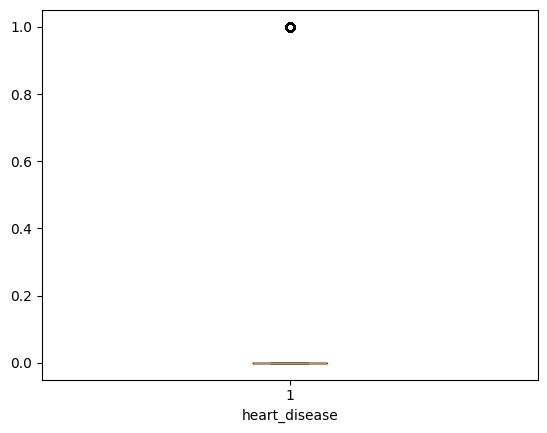

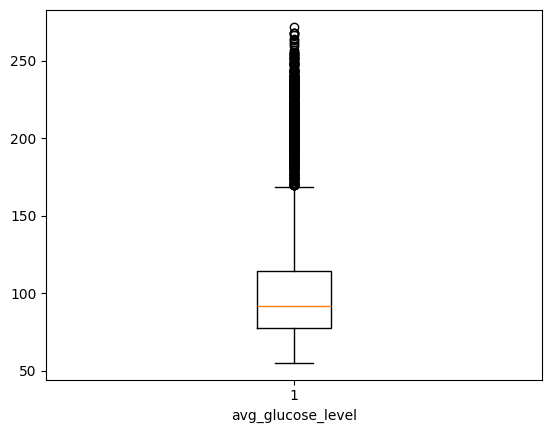

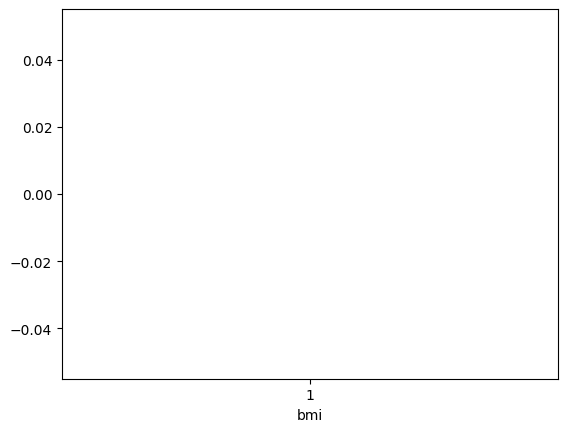

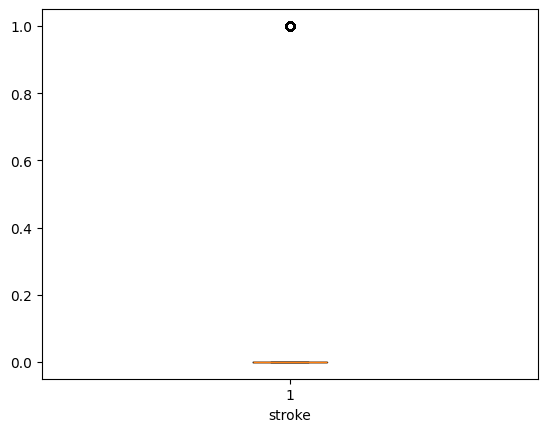

In [44]:
for i in col:
    if df[i].dtype in ['int64', 'float64']:
        plt.boxplot(df[i])
        plt.xlabel(i)
        plt.show()


In [45]:
import warnings
warnings.filterwarnings('ignore')


In [46]:
df['bmi'].fillna(df['bmi'].median(), inplace=True)    #Filling null values with median is a robust method in pre processing data

So far:

#BMI missing → median imputation

#No duplicates

#Max glucose is 271 mg/dl  and its clinically valid. So retained

#Hypertension / heart disease / stroke are risk indicators, not outliers

In [47]:
df['avg_glucose_level'].describe()


count    5110.000000
mean      106.147677
std        45.283560
min        55.120000
25%        77.245000
50%        91.885000
75%       114.090000
max       271.740000
Name: avg_glucose_level, dtype: float64

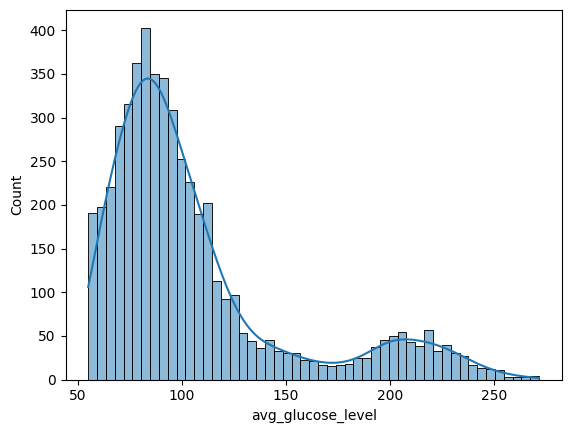

In [48]:
sns.histplot(df['avg_glucose_level'], kde=True)
plt.show()


In [49]:
df['avg_glucose_level'].skew()    # skewness >1

np.float64(1.5722838665030459)

# As average glucose level is highly skewed on the right, log transformation is done below,

In [50]:
df['avg_glucose_log'] = np.log(df['avg_glucose_level'])

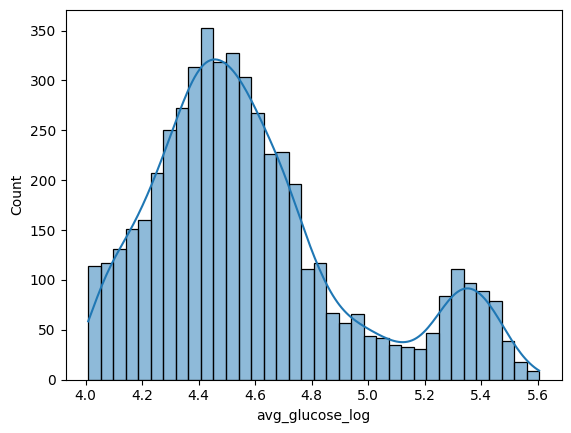

In [51]:
sns.histplot(df['avg_glucose_log'], kde=True)
plt.show()

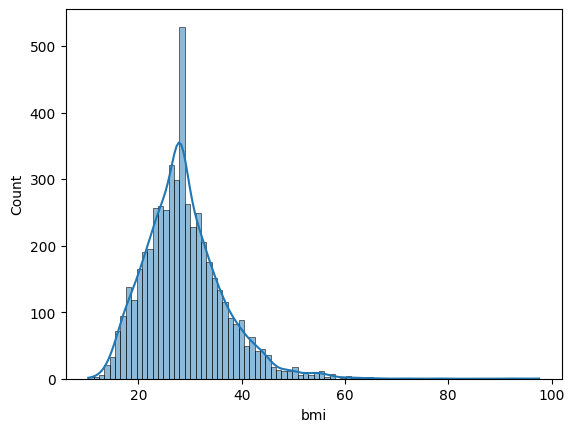

In [52]:
sns.histplot(df['bmi'], kde=True)
plt.show()

In [53]:
df['bmi'].skew()

np.float64(1.0881872326442346)

In [54]:
df['bmi_log'] = np.log(df['bmi'])

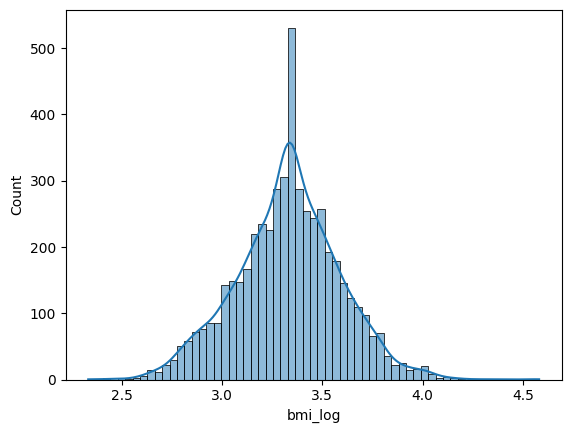

In [55]:
sns.histplot(df['bmi_log'], kde=True)
plt.show()

In [56]:
df.groupby('stroke')['age'].mean()


stroke
0    41.971545
1    67.728193
Name: age, dtype: float64

#Mean age among stroke patients (≈68 years) is significantly higher than non-stroke individuals (≈42 years), indicating strong age-related risk stratification in the dataset.

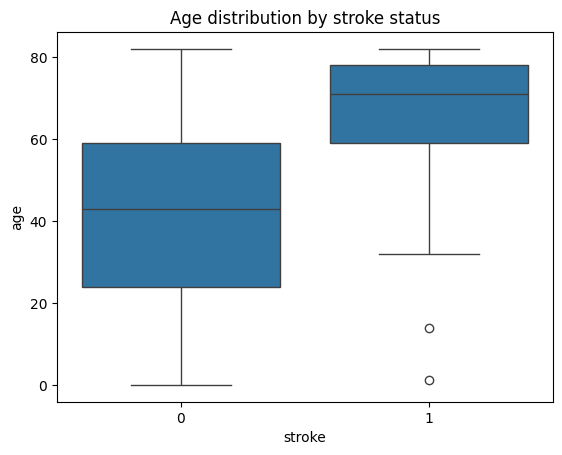

In [57]:
sns.boxplot(x='stroke', y='age', data=df)
plt.title("Age distribution by stroke status")
plt.show()

In [58]:
df.groupby('stroke')['avg_glucose_level'].mean()

stroke
0    104.795513
1    132.544739
Name: avg_glucose_level, dtype: float64

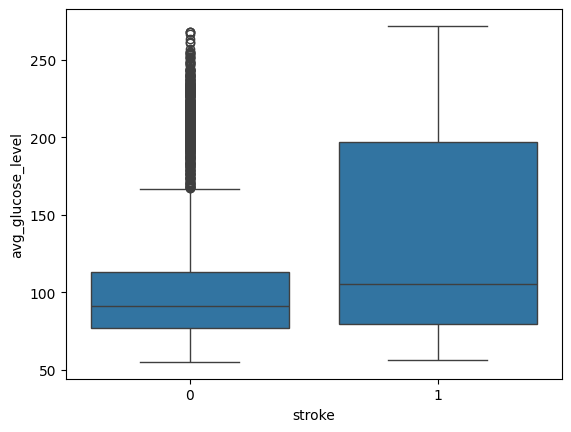

In [59]:
sns.boxplot(x='stroke', y='avg_glucose_level', data=df)
plt.show()


Insight:

Elevated blood glucose appears to be associated with increased stroke risk and may serve as an important metabolic risk indicator.



In [60]:
df.groupby('stroke')['bmi'].mean()

stroke
0    28.799115
1    30.090361
Name: bmi, dtype: float64

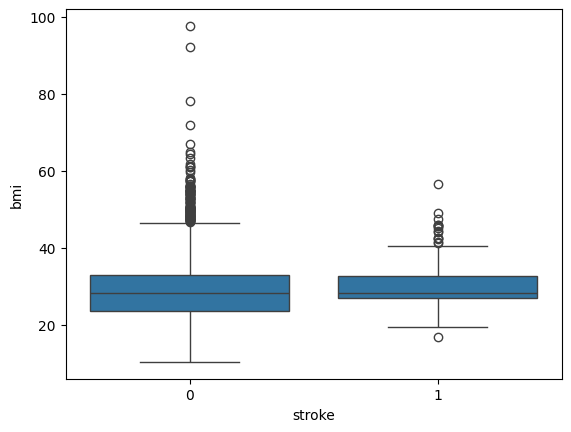

In [61]:
sns.boxplot(x='stroke', y='bmi', data=df)
plt.show()

Insight:

Average BMI is marginally higher among stroke patients (≈30.1) compared to non-stroke individuals (≈28.8), indicating a modest association with stroke risk relative to stronger predictors such as age and glucose.

In [62]:
pd.crosstab(df['hypertension'], df['stroke'], normalize='index')


stroke,0,1
hypertension,,
0,0.960321,0.039679
1,0.867470,0.132530


Text(0.5, 1.0, 'Stroke rate by hypertension status')

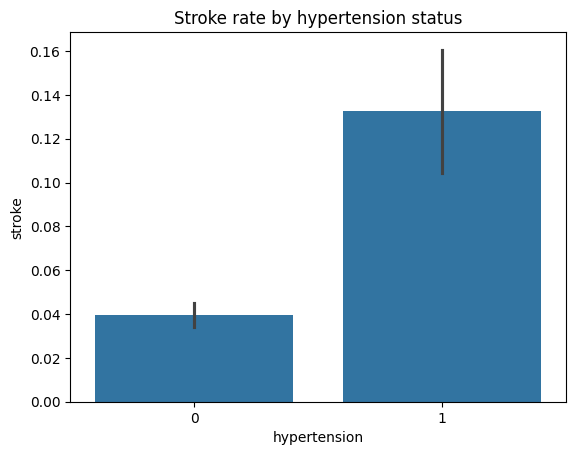

In [63]:
sns.barplot(x='hypertension', y='stroke', data=df)
plt.title("Stroke rate by hypertension status")


Insight: 

Stroke prevalence among hypertensive individuals (13.3%) is over three times higher than among non-hypertensive individuals (4.0%), indicating strong risk stratification by blood pressure status.

In [64]:
pd.crosstab(df['heart_disease'], df['stroke'], normalize='index')


stroke,0,1
heart_disease,,
0,0.958213,0.041787
1,0.829710,0.170290


Text(0.5, 1.0, 'Stroke rate by heart disease status')

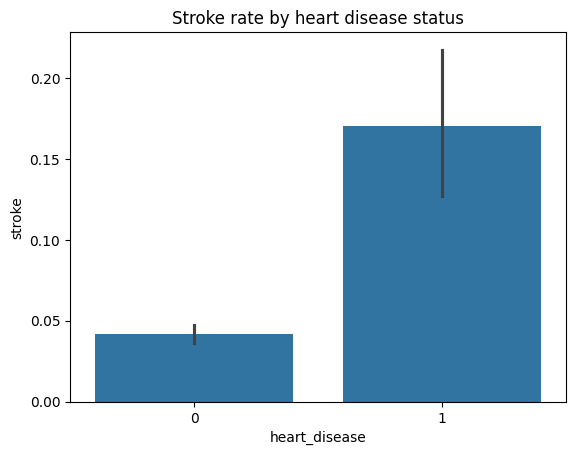

In [65]:
sns.barplot(x='heart_disease', y='stroke', data=df)
plt.title("Stroke rate by heart disease status")


Insight:

Stroke prevalence among individuals with heart disease (17%) is approximately four times higher than among those without heart disease (4%), indicating a strong cardiovascular risk association.

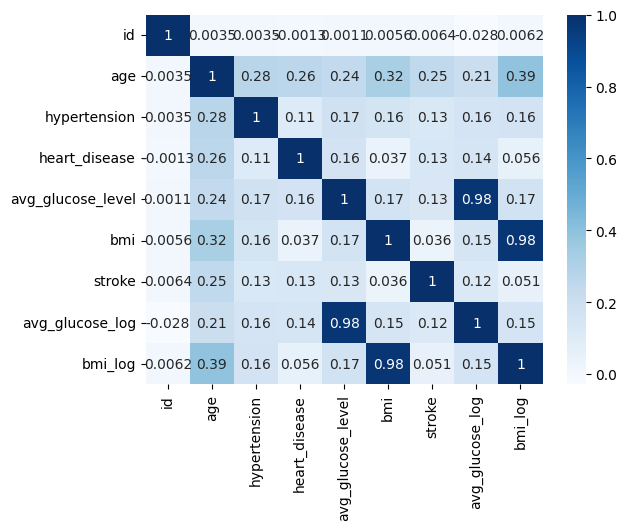

In [66]:
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='Blues')
plt.show()


Insights:

Correlation analysis reveals that age demonstrates the strongest positive association with stroke (r = 0.25), while hypertension (r = 0.13) and average glucose level (r = 0.12) show weaker but consistent positive relationships, suggesting their relevance as potential risk indicators.

or

Correlation analysis shows age has the strongest positive association with stroke (r ≈ 0.25), indicating that stroke risk tends to increase with age. However, the relationship is moderate, meaning age alone does not determine stroke occurrence. Hypertension and average glucose show weaker but consistent positive associations.

# Multiple analytical methods including correlation analysis, group comparisons, and model interpretability consistently indicate age, hypertension, and glucose as relevant stroke risk indicators.

In [67]:
features = [
    'age',
    'hypertension',
    'heart_disease',
    'avg_glucose_log',   # transformed
    'bmi_log'
]

X = df[features]
y = df['stroke']


In [68]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = LogisticRegression()
model.fit(X_train, y_train)

print(model.score(X_test, y_test))


0.9393346379647749


# Model score = 0.93 (accuracy)

The model achieved an accuracy of 93%. However, because stroke cases are relatively rare, accuracy alone is not a reliable indicator of performance. A model can achieve high accuracy by predicting most cases as non-stroke. Therefore, additional metrics such as ROC-AUC, Precision-Recall AUC, recall, and F1 score were used to evaluate minority class detection.

In [69]:
import pandas as pd
pd.Series(model.coef_[0], index=X.columns)


age                0.068957
hypertension       0.330581
heart_disease      0.321624
avg_glucose_log    0.504908
bmi_log            0.103807
dtype: float64

In [70]:
df['stroke'].value_counts(normalize=True)


stroke
0    0.951272
1    0.048728
Name: proportion, dtype: float64

In [71]:
y_prob = model.predict_proba(X_test)[:, 1]


In [72]:
from sklearn.metrics import roc_auc_score

auc = roc_auc_score(y_test, y_prob)
print("ROC AUC Score:", auc)


ROC AUC Score: 0.8516969086021505


#  ROC-AUC = 0.85

The model achieved an ROC-AUC of 0.85, indicating strong discrimination ability. This means the model can effectively distinguish between stroke and non-stroke cases across different probability thresholds.

Simply:

There is an 85% chance the model assigns a higher risk score to a stroke patient than to a non-stroke individual.

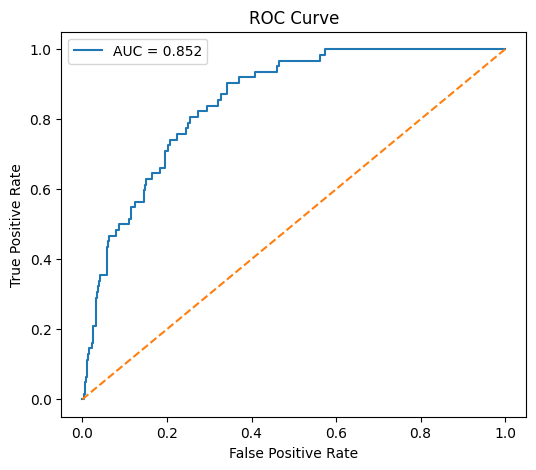

In [73]:
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt

fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f'AUC = {auc:.3f}')
plt.plot([0,1], [0,1], linestyle='--')  # random model line
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()


Insight:

The ROC curve shows strong separation between stroke and non-stroke classes, with performance well above random classification. The curve’s position toward the upper-left region indicates good sensitivity-specificity trade-off across thresholds.

In short:

# The ROC curve confirms good classification separability.

In [74]:
print(df['stroke'].value_counts())
print(df['stroke'].value_counts(normalize=True))


stroke
0    4861
1     249
Name: count, dtype: int64
stroke
0    0.951272
1    0.048728
Name: proportion, dtype: float64


In [75]:
from sklearn.metrics import precision_recall_curve

precision, recall, thresholds = precision_recall_curve(y_test, y_prob)


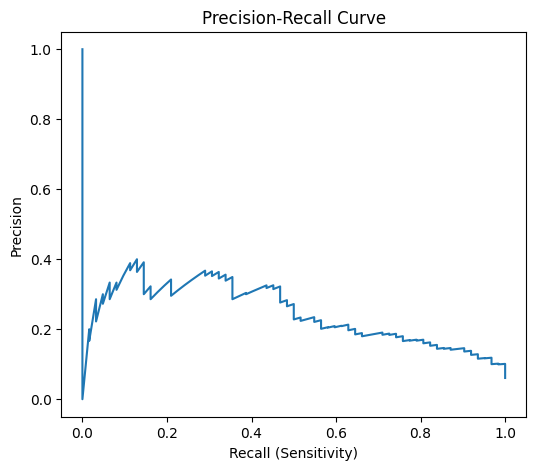

In [76]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,5))
plt.plot(recall, precision)
plt.xlabel("Recall (Sensitivity)")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.show()


In [77]:
from sklearn.metrics import average_precision_score

pr_auc = average_precision_score(y_test, y_prob)
print("PR AUC:", pr_auc)


PR AUC: 0.2507543481783133


# PR-AUC = 0.25

Because stroke is a minority class, Precision-Recall AUC was used to evaluate detection quality. The model achieved PR-AUC of 0.25, substantially above baseline prevalence, indicating meaningful ability to identify stroke cases despite class imbalance

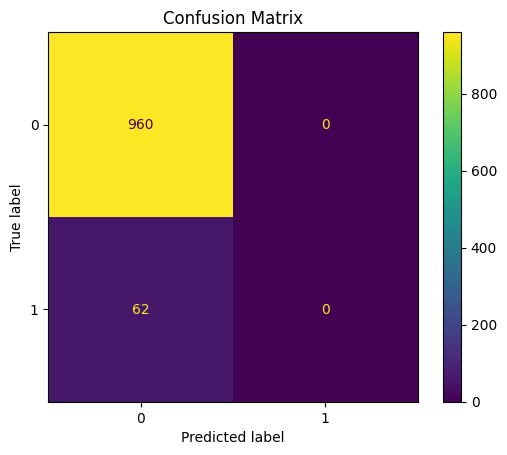

In [78]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

y_pred = model.predict(X_test)

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(cm)
disp.plot()
plt.title("Confusion Matrix")
plt.show()


Insight: 

At the default classification threshold, the model predicted all cases as non-stroke, resulting in perfect classification of the majority class but complete failure to detect stroke cases. This produced zero recall and F1 score for the positive class, highlighting the impact of class imbalance and threshold selection.

> After adjusting the classification threshold, stroke detection improved substantially, demonstrating that probability threshold selection is critical in imbalanced medical prediction tasks.

In [79]:
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LogisticRegression

cv_scores = cross_val_score(
    LogisticRegression(max_iter=1000),
    X, y,
    cv=5,
    scoring='roc_auc'
)

print("CV ROC-AUC scores:", cv_scores)
print("Mean ROC-AUC:", cv_scores.mean())


CV ROC-AUC scores: [0.8431893  0.83923868 0.83757202 0.84288066 0.84625711]
Mean ROC-AUC: 0.8418275527078608


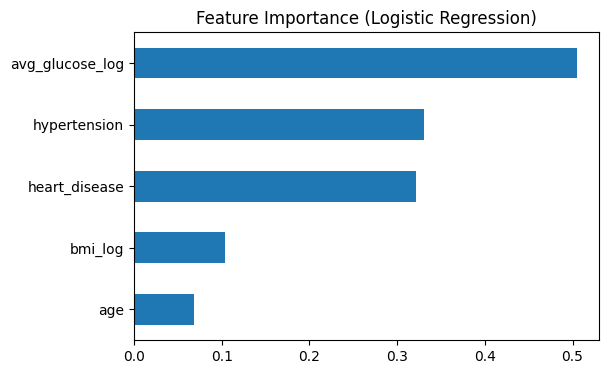

In [80]:
import pandas as pd

importance = pd.Series(model.coef_[0], index=X.columns)
importance.sort_values().plot(kind='barh', figsize=(6,4))
plt.title("Feature Importance (Logistic Regression)")
plt.show()


Insight: 

Logistic regression coefficients indicate glucose level has the strongest per-unit effect on stroke probability. However, coefficient magnitude reflects mathematical sensitivity rather than total predictive influence across the population.

In [81]:
pip install shap


Note: you may need to restart the kernel to use updated packages.


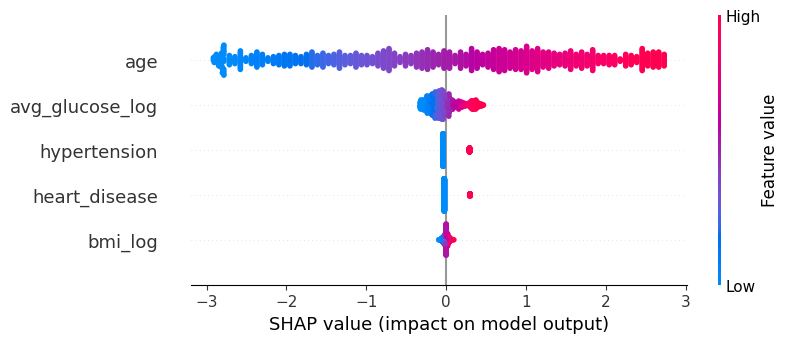

In [82]:
import shap

explainer = shap.Explainer(model, X_train)
shap_values = explainer(X_test)

shap.plots.beeswarm(shap_values)


# SHAP Summary Plot
SHAP explains how much each feature actually influenced model predictions across all patients that is, it measures real predictive impact.

Interpretation:

* Age is the most influential feature affecting stroke prediction.
* Higher age values consistently push predictions toward higher stroke risk.
* Average glucose (log) is the next strongest contributor.
* Hypertension and heart disease have moderate impact.
* BMI has the smallest effect.

 Insight:

SHAP analysis identifies age as the most influential predictor of stroke risk, followed by glucose levels. Hypertension and heart disease contribute moderate predictive impact, while BMI shows comparatively weaker influence. Feature effects align with established cardiovascular risk patterns.

In [83]:
y_pred = model.predict(X_test)


In [84]:
from sklearn.metrics import f1_score

f1 = f1_score(y_test, y_pred)
print("F1 Score:", f1)


F1 Score: 0.0


At the default classification threshold, the model predicted no stroke cases, resulting in zero recall and F1 score of 0. This occurred because predicted probabilities rarely exceeded the default threshold in the imbalanced dataset. After threshold adjustment, minority detection improved substantially.



In [85]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

           0       0.94      1.00      0.97       960
           1       0.00      0.00      0.00        62

    accuracy                           0.94      1022
   macro avg       0.47      0.50      0.48      1022
weighted avg       0.88      0.94      0.91      1022



In [86]:
y_prob = model.predict_proba(X_test)[:,1]


In [87]:
import numpy as np

y_pred_new = (y_prob > 0.2).astype(int)


In [88]:
from sklearn.metrics import classification_report, f1_score

print(classification_report(y_test, y_pred_new))
print("F1:", f1_score(y_test, y_pred_new))


              precision    recall  f1-score   support

           0       0.95      0.97      0.96       960
           1       0.30      0.21      0.25        62

    accuracy                           0.92      1022
   macro avg       0.63      0.59      0.60      1022
weighted avg       0.91      0.92      0.92      1022

F1: 0.24761904761904763


In [89]:
import numpy as np
from sklearn.metrics import precision_recall_curve

# Step 1 — get precision, recall, thresholds
precision, recall, thresholds = precision_recall_curve(y_test, y_prob)

# Step 2 — compute F1 safely (avoid divide-by-zero)
f1_scores = 2 * precision * recall / (precision + recall + 1e-8)

# Step 3 — remove last F1 (no matching threshold)
f1_scores = f1_scores[:-1]

# Step 4 — find best threshold
best_index = np.argmax(f1_scores)
best_threshold = thresholds[best_index]
best_f1 = f1_scores[best_index]

print(f"Optimal threshold: {best_threshold:.3f}")
print(f"Best F1 score: {best_f1:.3f}")


Optimal threshold: 0.151
Best F1 score: 0.382


In [90]:
y_pred_opt = (y_prob >= best_threshold).astype(int)


In [91]:
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred_opt))


              precision    recall  f1-score   support

           0       0.96      0.94      0.95       960
           1       0.32      0.47      0.38        62

    accuracy                           0.91      1022
   macro avg       0.64      0.70      0.67      1022
weighted avg       0.93      0.91      0.92      1022



Insight:

After optimizing the classification threshold, stroke recall increased to 47%, enabling detection of nearly half of stroke cases. This improvement came with moderate precision (32%), reflecting increased false positives typical of screening-oriented models. The resulting F1 score of 0.38 indicates improved balance between sensitivity and prediction reliability.

## Conclusion


This project explored stroke risk prediction using an imbalanced healthcare dataset and an interpretable machine learning pipeline.

Exploratory analysis revealed meaningful clinical risk patterns. Stroke prevalence increased substantially with age, elevated glucose levels, hypertension, and heart disease, while BMI showed comparatively weaker association. These findings align with known cardiovascular risk mechanisms.

A logistic regression model was developed as a baseline interpretable classifier. Although overall accuracy was high due to class imbalance, minority class detection required careful evaluation using ROC-AUC, Precision-Recall AUC, and F1 score. The model demonstrated strong discrimination ability (ROC-AUC ≈ 0.85) and meaningful detection performance above baseline prevalence.

Initial classification using the default probability threshold failed to detect stroke cases. After threshold adjustment and optimization using precision-recall analysis, minority detection improved significantly, highlighting the importance of operating-point selection in imbalanced medical prediction tasks.

Model explainability using SHAP identified age as the most influential predictor, followed by glucose levels, hypertension, and heart disease. Feature contributions were clinically plausible and consistent with exploratory analysis, supporting model interpretability and reliability.

Overall, this project demonstrates how careful preprocessing, imbalance-aware evaluation, threshold tuning, and explainable modeling can produce meaningful insights from real-world healthcare data.

Future work may include advanced models, cost-sensitive learning, external validation, and deployment-ready risk scoring tools for screening support.

## Key Takeaways (Plain Language)
[Simple version]:



- This project built a machine learning model to identify people at higher risk of stroke using health and lifestyle information. The model was able to distinguish higher-risk and lower-risk individuals reasonably well, even though stroke cases were relatively rare in the dataset.

- Age emerged as the most important risk indicator, followed by blood glucose levels, hypertension, and heart disease. These findings are consistent with established medical knowledge about stroke risk.

- Initially, the model missed many stroke cases because rare events are harder to detect. After adjusting how predictions were classified, the model became much better at identifying individuals who may require closer monitoring or preventive care.

- Overall, the results show that interpretable machine learning can help highlight meaningful risk patterns and support early screening decisions in healthcare settings.

## Technical Summary
[Metric version]

- The logistic regression model achieved 93% accuracy, though accuracy alone is insufficient due to class imbalance. The model demonstrated strong discrimination with ROC-AUC of 0.85. Precision-Recall AUC of 0.25 indicates meaningful detection ability above baseline prevalence. Initial predictions yielded zero F1 score due to conservative thresholding, but performance improved after threshold adjustment. Feature interpretation using SHAP identified age as the most influential predictor, followed by glucose levels, consistent with observed clinical risk patterns

In [93]:
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score
import pandas as pd

In [96]:
models = {
    "Logistic Regression": LogisticRegression(
        max_iter=1000,
        class_weight='balanced',
        random_state=42
    ),
    "Random Forest": RandomForestClassifier(
        n_estimators=100,
        class_weight='balanced',
        random_state=42
    ),
    "XGBoost": XGBClassifier(
        use_label_encoder=False,
        eval_metric='logloss',
        scale_pos_weight=len(y_train[y_train==0])/len(y_train[y_train==1]),
        random_state=42
    )
}

In [97]:
results = []

for name, model in models.items():
    model.fit(X_train, y_train)
    y_prob = model.predict_proba(X_test)[:, 1]
    auc = roc_auc_score(y_test, y_prob)
    results.append({"Model": name, "ROC-AUC": round(auc, 3)})

results_df = pd.DataFrame(results)
print(results_df.sort_values("ROC-AUC", ascending=False))

                 Model  ROC-AUC
0  Logistic Regression    0.852
1        Random Forest    0.801
2              XGBoost    0.784


In [98]:
from sklearn.metrics import roc_auc_score
import numpy as np

# Get probabilities from each model
lr_prob = models["Logistic Regression"].predict_proba(X_test)[:, 1]
rf_prob = models["Random Forest"].predict_proba(X_test)[:, 1]
xgb_prob = models["XGBoost"].predict_proba(X_test)[:, 1]

# Average ensemble
ensemble_prob = (lr_prob + rf_prob + xgb_prob) / 3

# Evaluate
ensemble_auc = roc_auc_score(y_test, ensemble_prob)
print(f"Ensemble ROC-AUC: {round(ensemble_auc, 3)}")

Ensemble ROC-AUC: 0.851
